# Clustering: Client Groups

Step 1. Import Libraries and Load Dataset

In [47]:
import numpy as np
np.random.seed(42) # necessary to stabilize comparison

import pandas as pd
pd.set_option("display.max_columns", None)  # Show all columns

import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, MeanShift, DBSCAN, estimate_bandwidth
from sklearn.neighbors import NearestNeighbors

In [48]:
original_df = pd.read_csv('marketing_campaign.csv', sep='\t')
processed_df = original_df.copy()


Step 2. Analyze and Clean Data

In [49]:
processed_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [50]:
processed_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [51]:
columns = [
    "Z_CostContact",
    "Z_Revenue",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain"
]

for col in columns:
    print(f"\n{'=' * 40}")
    print(f"Value counts for: {col}")
    print(f"{'=' * 40}")
    print(processed_df[col].value_counts())


Value counts for: Z_CostContact
Z_CostContact
3    2240
Name: count, dtype: int64

Value counts for: Z_Revenue
Z_Revenue
11    2240
Name: count, dtype: int64

Value counts for: AcceptedCmp1
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

Value counts for: AcceptedCmp2
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

Value counts for: AcceptedCmp3
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64

Value counts for: AcceptedCmp4
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64

Value counts for: AcceptedCmp5
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int64

Value counts for: Complain
Complain
0    2219
1      21
Name: count, dtype: int64


In [52]:
#'Z_CostContact' and 'Z_Revenue' were removed because both contained a constant value, which means 
# they were increasing the dimentions without adding information.
processed_df.drop('Z_CostContact', axis=1, inplace=True)
processed_df.drop('Z_Revenue', axis=1, inplace=True)
processed_df.drop('ID', axis=1, inplace=True) #provides no information

In [53]:
processed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

The features 'Education', 'Marital Status' and 'Dt_Customer' are stored as object instead of float64 or int64. These features will be encoded.

In [54]:
education_unique = processed_df.Education.unique() 
print(f"All education unique values: {education_unique}\n")

marital_unique = processed_df.Marital_Status.unique() 
print(f"All marital unique values: {marital_unique}\n")

dt_unique = processed_df.Dt_Customer.unique() # Convert dates to int
print(f"All dt unique values: {dt_unique}\n")


All education unique values: <StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

All marital unique values: <StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str

All dt unique values: <StringArray>
['04-09-2012', '08-03-2014', '21-08-2013', '10-02-2014', '19-01-2014',
 '09-09-2013', '13-11-2012', '08-05-2013', '06-06-2013', '13-03-2014',
 ...
 '27-03-2014', '15-12-2012', '17-09-2012', '02-06-2013', '21-12-2012',
 '01-11-2013', '10-08-2013', '11-10-2012', '20-12-2012', '09-01-2014']
Length: 663, dtype: str



In [55]:
processed_df.Marital_Status.value_counts() 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

From the Marital_Status feature, the Alone values will be set equal to 'Single', while rows containing 'Absurd' and 'YOLO' will be deleted.  
As for the Dt_Customer feature, dates will be converted to int.

In [56]:
# Replace Alone with Single
processed_df['Marital_Status'] = processed_df['Marital_Status'].replace({'Alone': 'Single'})
# create a Boolean mask for the rows to remove
# then select and keep all rows except the ones that contain the values to be removed
mask = (processed_df['Marital_Status'] == 'Absurd') | (processed_df['Marital_Status'] == 'YOLO')
processed_df = processed_df[~mask].copy()
# Binary Encoding for Marital Status
processed_df = ce.BinaryEncoder(cols=['Marital_Status'], return_df = True).fit_transform(processed_df)

#Ordinal Encoding for 'Education'
educ_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
OE_educ = OrdinalEncoder(categories=[educ_order])
processed_df['Education'] = OE_educ.fit_transform(processed_df[['Education']])

# Convert time dtype = object to dtype = datetime64 
# This code will output not a measure of nanoseconds, but of days since epoch
processed_df['Dt_Customer'] = (
    pd.to_datetime(processed_df['Dt_Customer'], dayfirst=True, format='%d-%m-%Y')
    .astype('int64') // 10**9 // 86400)

processed_df.head()


,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,2.0,0,0,1,58138.0,0,0,15,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,1954,2.0,0,0,1,46344.0,1,1,16,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,1965,2.0,0,1,0,71613.0,0,0,15,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,1984,2.0,0,1,0,26646.0,1,0,16,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,1981,4.0,0,1,1,58293.0,1,0,16,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [57]:
print(f'Total duplicates detected = {sum(processed_df.duplicated())}\n')

na_df = processed_df.isna()
for column in list(na_df.columns):
    print(f'Total missing data in feature "{column}" = {sum(na_df[column])}')


Total duplicates detected = 183

Total missing data in feature "Year_Birth" = 0
Total missing data in feature "Education" = 0
Total missing data in feature "Marital_Status_0" = 0
Total missing data in feature "Marital_Status_1" = 0
Total missing data in feature "Marital_Status_2" = 0
Total missing data in feature "Income" = 24
Total missing data in feature "Kidhome" = 0
Total missing data in feature "Teenhome" = 0
Total missing data in feature "Dt_Customer" = 0
Total missing data in feature "Recency" = 0
Total missing data in feature "MntWines" = 0
Total missing data in feature "MntFruits" = 0
Total missing data in feature "MntMeatProducts" = 0
Total missing data in feature "MntFishProducts" = 0
Total missing data in feature "MntSweetProducts" = 0
Total missing data in feature "MntGoldProds" = 0
Total missing data in feature "NumDealsPurchases" = 0
Total missing data in feature "NumWebPurchases" = 0
Total missing data in feature "NumCatalogPurchases" = 0
Total missing data in feature "

In [58]:
# Keeping observations with missing data
mean_median = (np.mean(processed_df.Income), np.median(processed_df.Income))
print(mean_median)
# In order to conserve the original data, na income will be replaced with the mean of income
income_mean = mean_median[0]
processed_df['Income'] = processed_df['Income'].fillna(income_mean)

processed_df.drop_duplicates(inplace=True)
print(f'Total duplicates detected = {sum(processed_df.duplicated())}\n')


(np.float64(52232.51084990959), np.float64(nan))
Total duplicates detected = 0



Step 3. Transform Data 

In [59]:
# scale features

features = ['Year_Birth', 
            'Education',
            'Income', 
            'Kidhome', 
            'Teenhome', 
            'Dt_Customer',
            'Recency', 
            'MntWines', 
            'MntFruits', 
            'MntMeatProducts',
            'MntFishProducts', 
            'MntSweetProducts', 
            'MntGoldProds',
            'NumDealsPurchases', 
            'NumWebPurchases', 
            'NumCatalogPurchases',
            'NumStorePurchases', 
            'NumWebVisitsMonth', 
]

    
RS = RobustScaler()
dataset = processed_df[features].reset_index(drop=True)
data = RS.fit_transform(dataset)
df_mask = pd.DataFrame(data, columns=features)
processed_df[features] = df_mask.values

processed_df.head()

,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,-0.722222,0.0,0,0,1,0.186166,0.0,0.0,0.0,0.18,0.958506,2.50000,2.238318,3.404255,2.424242,1.361702,0.5,1.00,2.00,-0.2,0.25,0,0,0,0,0,0,1
1,-0.888889,0.0,0,0,1,-0.175913,1.0,1.0,1.0,-0.22,-0.336100,-0.21875,-0.285047,-0.212766,-0.212121,-0.382979,0.0,-0.75,-0.25,-0.6,-0.25,0,0,0,0,0,0,0
2,-0.277778,0.0,0,1,0,0.599853,0.0,0.0,0.0,-0.46,0.524896,1.28125,0.280374,2.106383,0.393939,0.382979,-0.5,1.00,0.00,1.0,-0.50,0,0,0,0,0,0,0
3,0.777778,0.0,0,1,0,-0.780647,1.0,0.0,1.0,-0.46,-0.336100,-0.12500,-0.219626,-0.042553,-0.151515,-0.404255,0.0,-0.50,-0.50,-0.2,0.00,0,0,0,0,0,0,0
4,0.611111,2.0,0,1,1,0.190925,1.0,0.0,1.0,0.90,0.000000,1.09375,0.238318,0.723404,0.575758,-0.191489,1.5,0.25,0.25,0.2,-0.25,0,0,0,0,0,0,0


In [60]:
processed_df.describe()

,Year_Birth,Education,Marital_Status_0,Marital_Status_1,Marital_Status_2,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000,2053.000000
mean,-0.068463,0.462737,0.139795,0.641013,0.641013,0.008458,0.446176,0.509498,0.349245,0.000214,0.271783,0.569061,0.470786,0.536319,0.581927,0.419801,0.168047,0.024233,0.164759,0.154116,-0.169873,0.073551,0.076961,0.071603,0.065270,0.012664,0.009742,0.151486
std,0.664749,1.005928,0.346859,0.479820,0.479820,0.779678,0.537712,0.546594,0.476848,0.579736,0.698858,1.242028,1.067336,1.158710,1.265029,1.104924,0.971455,0.699827,0.732856,0.648539,0.609608,0.261102,0.266594,0.257891,0.247062,0.111849,0.098243,0.358609
min,-4.277778,-2.000000,0.000000,0.000000,0.000000,-1.545575,0.000000,0.000000,0.000000,-0.980000,-0.358921,-0.250000,-0.313084,-0.255319,-0.242424,-0.510638,-1.000000,-1.000000,-0.500000,-1.000000,-1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.611111,0.000000,0.000000,0.000000,0.000000,-0.502656,0.000000,0.000000,0.000000,-0.500000,-0.311203,-0.218750,-0.238318,-0.191489,-0.212121,-0.319149,-0.500000,-0.500000,-0.500000,-0.400000,-0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.388889,1.000000,0.000000,1.000000,1.000000,0.497344,1.000000,1.000000,1.000000,0.500000,0.688797,0.781250,0.761682,0.808511,0.787879,0.680851,0.500000,0.500000,0.500000,0.600000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.444444,2.000000,1.000000,1.000000,1.000000,18.868142,2.000000,2.000000,1.000000,1.000000,2.738589,5.968750,7.747664,5.255319,7.727273,7.191489,6.500000,5.750000,6.500000,1.600000,3.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [61]:
print(processed_df.shape)

(2053, 28)


Step 4. Train Models

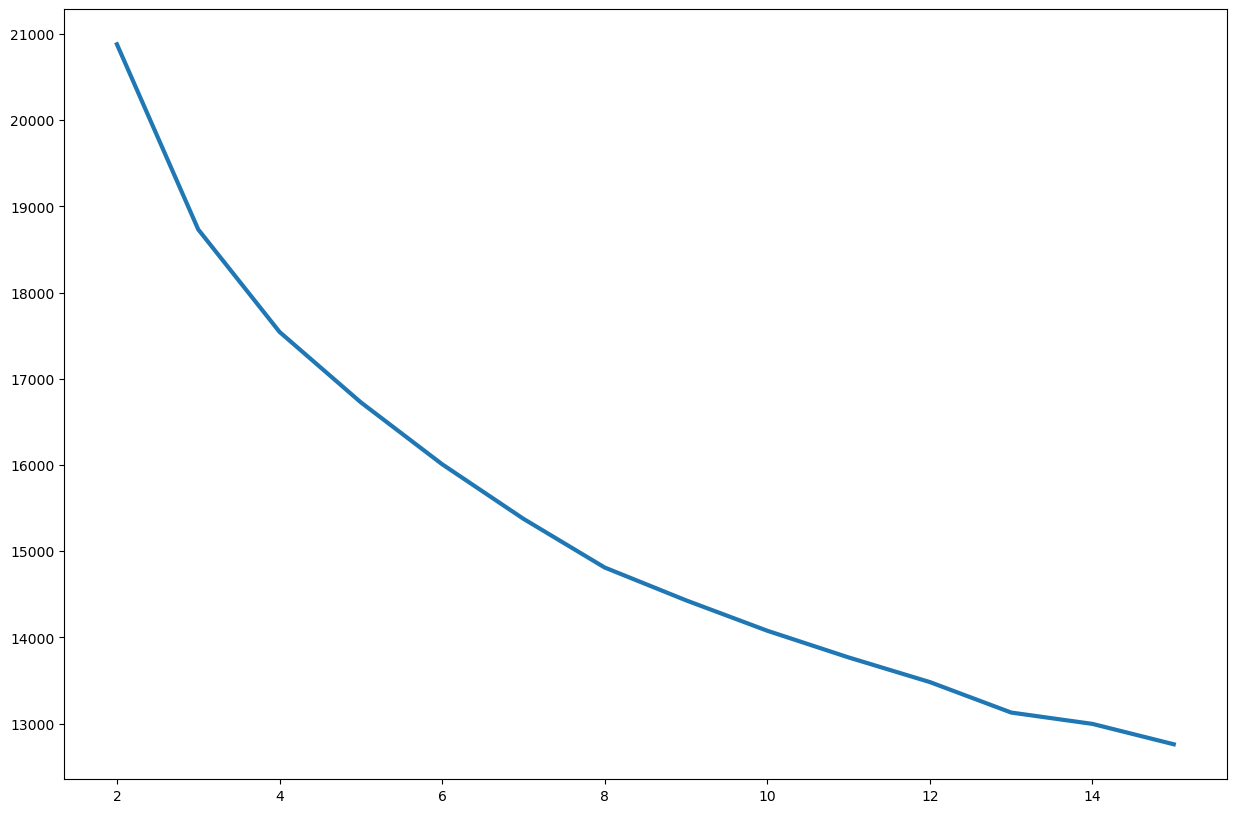

In [ ]:
# Kmeans clusters
    
inertias = []

for i in range(2, 16):
    model = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42).fit(processed_df)
    inertias.append(model.inertia_)
    
plt.figure(figsize = (15, 10))
plt.plot(range(2, 16), inertias, linewidth = 3)
plt.show()


In [65]:
for i in range(2, 16):
    model = KMeans(n_clusters=i, n_init=10, random_state=42)

    labels = model.fit_predict(processed_df)

    score = silhouette_score(processed_df, labels)

    print(f'i={i}, silhouette={score:.4f}')

i=2, silhouette=0.3237
i=3, silhouette=0.1881
i=4, silhouette=0.1801
i=5, silhouette=0.1113
i=6, silhouette=0.1142
i=7, silhouette=0.1198
i=8, silhouette=0.1190
i=9, silhouette=0.1177
i=10, silhouette=0.1190
i=11, silhouette=0.1023
i=12, silhouette=0.1024
i=13, silhouette=0.1190
i=14, silhouette=0.0921
i=15, silhouette=0.0969


In [66]:
chosen_c = 5 # 5 clusters
kmeans_model = KMeans(n_clusters=chosen_c, init='k-means++').fit(processed_df)

In [67]:
# MeanShift Clusters

# Estimate bandwith values
base_bandwidth = estimate_bandwidth(processed_df, quantile=0.3, n_samples=500)
print("Estimated bandwidth:", base_bandwidth)
bandwidth_values = np.linspace(base_bandwidth * 0.5, base_bandwidth * 2.0, 10)

best_bandwidth = None
best_score = -1 # Higher silhouette scores indicate better-defined clusters

for bandwidth in bandwidth_values:
    model = MeanShift(bandwidth=bandwidth).fit(processed_df)
    labels = model.labels_

    n_clusters = len(set(labels))
    if n_clusters > 1:
        score = silhouette_score(processed_df, labels) # Use to choose the best bandwith, from -1 to 1
        if score > best_score:
            best_score = score
            best_bandwidth = bandwidth

print(f"Best Bandwidth: {best_bandwidth}, Best Silhouette Score: {best_score}")


Estimated bandwidth: 3.9736972454965263
Best Bandwidth: 7.9473944909930525, Best Silhouette Score: 0.5896562341670768


In [68]:
meanshift_model = MeanShift(bandwidth=best_bandwidth).fit(processed_df)

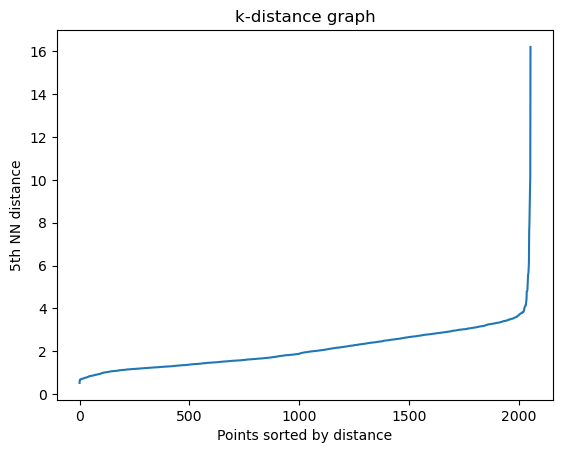

In [69]:
# Estimate min_samples
# Use min_samples = 5
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(processed_df)
distances, indices = neighbors_fit.kneighbors(processed_df)

# Sort distances of the 5th nearest neighbor
distances = np.sort(distances[:, 4])  # 4 = index for 5th neighbor
plt.plot(distances)
plt.ylabel("5th NN distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph")
plt.show()


In [77]:

# ideal epsi value around 4
epsi_vals = [2, 2.5, 3, 4, 4.5]
min_samples_vals = [3, 5, 10, 15, 20]

best_epsi = None
best_min_samples = None
best_davies_bouldin_index = float('inf')

for eps in epsi_vals:
    for min_sample in min_samples_vals:
        labels = DBSCAN(eps=eps, min_samples=min_sample).fit_predict(processed_df)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            score = davies_bouldin_score(processed_df, labels)

            if score < best_davies_bouldin_index:
                best_davies_bouldin_index = score
                best_epsi = eps
                best_min_samples = min_sample

print(
    f"\nBest Davies-Bouldin Index: {best_davies_bouldin_index}. "
    f"Best Epsilon: {best_epsi}, "
    f"Best Min Samples: {best_min_samples}"
)




Best Davies-Bouldin Index: 1.8260825687382471. Best Epsilon: 2.5, Best Min Samples: 3


In [78]:
dbscan_model = DBSCAN(eps=best_epsi, min_samples=best_min_samples).fit(processed_df)

Step 5. Compare Models

In [79]:

def model_scores(models, names, df):

    results = dict()
    for model, name in zip(models,names):
        labels = model.labels_
        #print(len(set(labels))) #To see number of groups created
        model_score = davies_bouldin_score(df, labels)
        results[name] = model_score
    
    return results

print(model_scores((kmeans_model, meanshift_model, dbscan_model), ('Kmeans', 'MeanShift', 'DBSCAN'), processed_df))

{'Kmeans': 2.0851949389909286, 'MeanShift': 0.5316489967549339, 'DBSCAN': 1.8260825687382471}


In [80]:
cluster_labels = set(meanshift_model.labels_)
cluster_labels

{np.int64(0), np.int64(1), np.int64(2)}

As a rough guideline, Davies-Bouldin index values below 1 are often considered indicative of good clustering quality. Based on this metric, the MeanShift model achieved the best performance with a Davies-Bouldin score of 0.53 while producing 3 distinct clusters.

In [84]:
cluster_labels = meanshift_model.labels_

processed_df['Cluster'] = meanshift_model.labels_

cluster_means = (processed_df.groupby('Cluster').mean(numeric_only=True).round(2))
cluster_medians = (processed_df.groupby('Cluster').median(numeric_only=True).round(2))

cluster_means.to_csv('cluster_means.csv')
cluster_medians.to_csv('cluster_medians.csv')